### Testing Deconvolution

This code is meant to demonstrate how parameter optimization of OASIS deconvolution improves true positives while limiting true negative calcium events in 2-photon imaging data



In [16]:
import sys
from pathlib import Path
import os
parent = Path.cwd().joinpath('..').resolve().as_posix()
sys.path.insert(0, os.path.join(parent, 'pyspell'))

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.ndimage import gaussian_filter1d, generic_filter
from scipy.fft import fft, fftfreq

import deconvolution as dc
from s2pfuns import (postProcess, _process_single_cell_foopsi,correct_spike_drift,
                     sgolay_detrend, percentile_detrend, highpass_detrend, als_detrend)

from scipy.ndimage import percentile_filter

# import linregress
from scipy.stats import linregress

Load dataset

In [11]:
# Load data
self = postProcess(s2ppath=r"X:\John\Subjects - GCaMP Recordings\L612_F_RightPFC_L6Chrimson_PFCgcamp8f_Panrec\SDswitch_day9_FOV1_optoRec\SDswitch_day9_FOV1_optoRec_img\suite2p\plane0")

Some basic parameters

In [21]:
# Options: 'sgolay', 'percentile', 'highpass', 'als', 'combined'
detrend_method = 'percentile'
fr             = 7.5 # frame rate
ar_model       = 2   # binary autoregressive model
neuron_idx     = 31  # index of neuron to test

The code below is the equivalent to running

```self.postProcess.cleanup_raw_traces(njobs=-1, verbose=1)```

but for a single neuron instead of all neurons

=== RUN 1: Baseline (optimize_g=0) ===
Running deconvolution with method OASIS
  Spikes detected: 1403, sn=3.7227, g=[ 1.45754973 -0.4734625 ]

=== RUN 2: Optimize g (using 10% of Run 1 spikes) ===
Running deconvolution with method OASIS
  Spikes detected: 1099, sn=3.7227, g=[ 1.66344493 -0.67616521]

=== Refining noise estimate from residuals ===
  sn from Run 2: 3.7227
  sn refined (MAD): 4.3847
  s_min threshold (10th pct): 0.5239

=== RUN 3: Final (refined sn + s_min + optimized g) ===
Running deconvolution with method OASIS
  Spikes detected: 687

=== Spike Drift Correction (Tim's peak-based method) ===
  Correction ratio range: [0.119, 1.070]
  Mean correction ratio: 0.306

SUMMARY: Spike counts across runs
  Run 1 (baseline):           1403 spikes
  Run 2 (optimize_g):         1099 spikes
  Run 3 (sn + s_min + g):     687 spikes
  Final (drift-corrected):    687 spikes


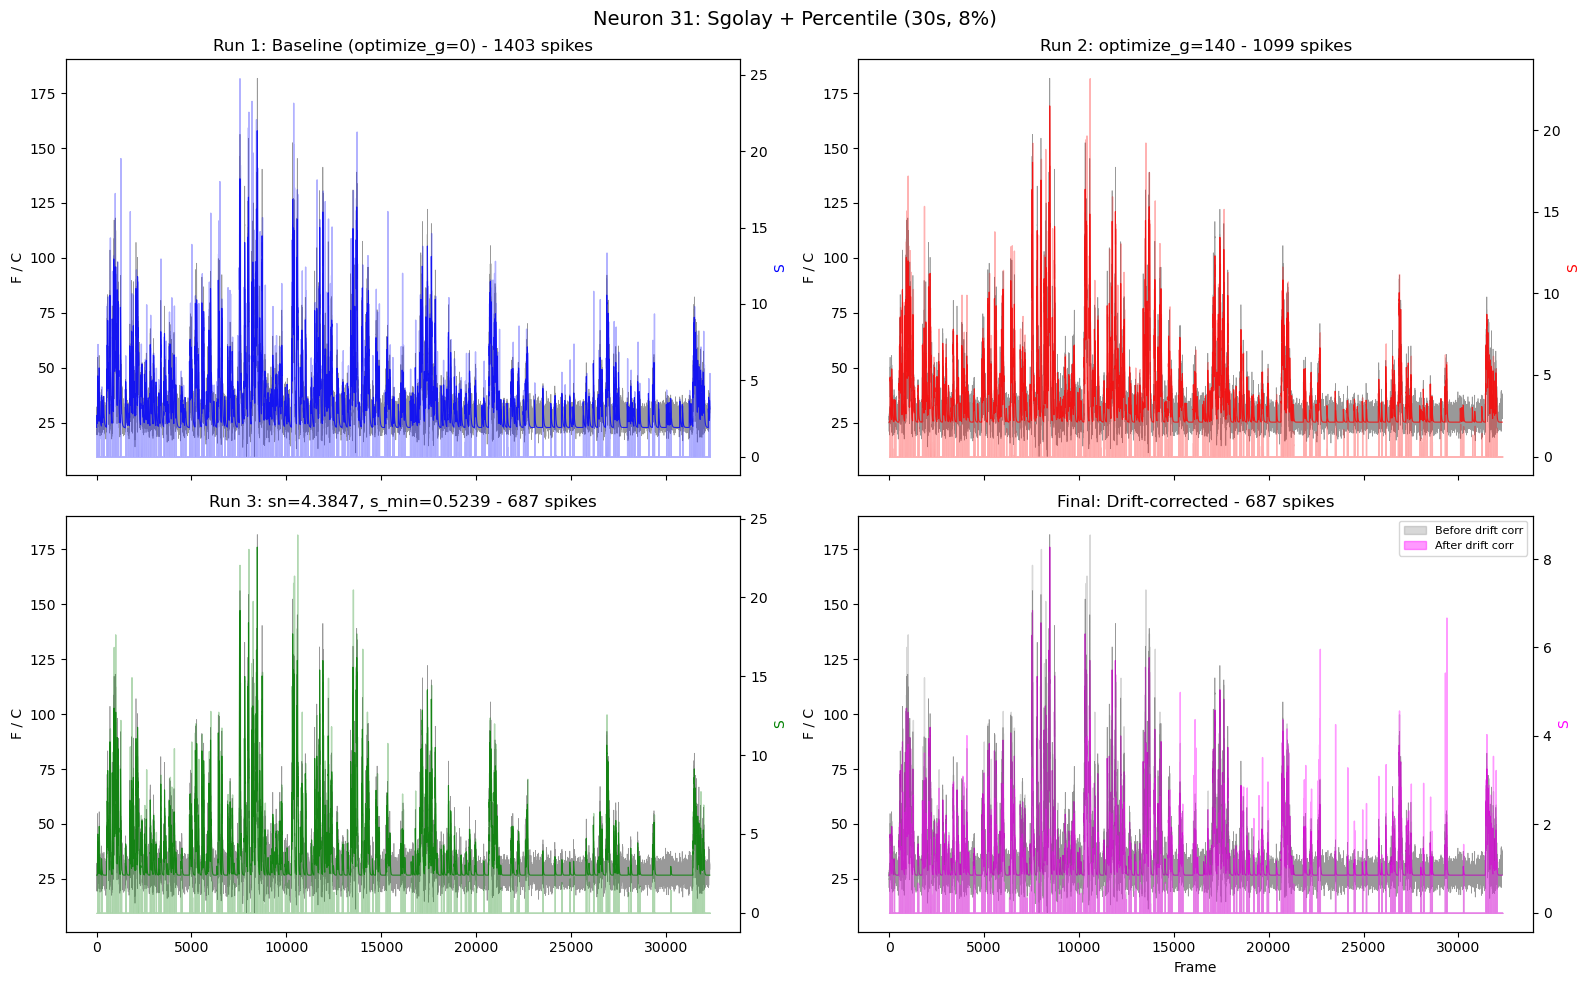

In [ ]:
# neuropil correct
Fc = self.F[neuron_idx, :] - self.Fneu[neuron_idx, :]

# =============================================================================
# Signal detrending
# =============================================================================

# APPLY SELECTED DETRENDING METHOD
if detrend_method == 'sgolay':
    f_processed, trend = sgolay_detrend(Fc, fr=fr, window_size=1001, add_median_back=True)
    method_label = "Sgolay (win=1001)"
    
elif detrend_method == 'percentile':
    # First apply sgolay, then percentile to catch remaining wiggle
    f_temp, _ = sgolay_detrend(Fc, fr=fr, window_size=1001, add_median_back=True)
    f_processed, trend = percentile_detrend(f_temp, fr=fr, window_sec=30, percentile=8, add_median_back=True)
    method_label = "Sgolay + Percentile (30s, 8%)"
    
elif detrend_method == 'highpass':
    f_processed, trend = highpass_detrend(Fc, fr=fr, cutoff_hz=0.005, add_median_back=True)
    method_label = "High-pass (0.005 Hz)"
    
elif detrend_method == 'als':
    f_processed, trend = als_detrend(Fc, lam=1e8, p=0.005, add_median_back=True)
    method_label = "ALS (lam=1e8, p=0.005)"
    
elif detrend_method == 'combined':
    # Aggressive: sgolay -> percentile -> check for remaining drift
    f_temp, _ = sgolay_detrend(Fc, fr=fr, window_size=1001, add_median_back=True)
    f_processed, trend = percentile_detrend(f_temp, fr=fr, window_sec=20, percentile=5, add_median_back=True)
    method_label = "Combined (sgolay + percentile 20s, 5%)"

else:
    f_processed, trend = sgolay_detrend(Fc, fr=fr, window_size=1001, add_median_back=True)
    method_label = "Sgolay (default)"

# =============================================================================
# TWO-PASS OPTIMIZATION TESTING
# Compare: (1) baseline, (2) optimize_g, (3) refined sn, (4) s_min threshold
# =============================================================================

# --- RUN 1: Baseline with optimize_g=0 ---
print("=== RUN 1: Baseline (optimize_g=0) ===")
c1_run, bl1, c1_init, g1, sn1, sp1, lam1 = dc.constrained_foopsi(
    f_processed, p=ar_model, method_deconvolution='oasis', bas_nonneg=True,
    noise_range=[0.25, .5], noise_method='logmexp', sn=None,
    lags=5, fudge_factor=1.0, solvers=None, verbosity=True, s_min=None,
    optimize_g=0
)
num_spikes_run1 = np.sum(sp1 > 0)
print(f"  Spikes detected: {num_spikes_run1}, sn={sn1:.4f}, g={g1}")

# --- RUN 2: Optimize g using 10% of detected spikes ---
print("\n=== RUN 2: Optimize g (using 10% of Run 1 spikes) ===")
optimized_g = max(1, int(num_spikes_run1 * 0.1))  # at least 1
c2_run, bl2, c2_init, g2, sn2, sp2, lam2 = dc.constrained_foopsi(
    f_processed, p=ar_model, method_deconvolution='oasis', bas_nonneg=True,
    noise_range=[0.25, .5], noise_method='logmexp', sn=None,
    lags=5, fudge_factor=1.0, solvers=None, verbosity=True, s_min=None,
    optimize_g=optimized_g
)
num_spikes_run2 = np.sum(sp2 > 0)
print(f"  Spikes detected: {num_spikes_run2}, sn={sn2:.4f}, g={g2}")

# --- Refine sn from residuals of Run 2 ---
print("\n=== Refining noise estimate from residuals ===")

# Rescale c2_run to match f_processed scale
c2_rescaled = c2_run * (np.std(f_processed) / (np.std(c2_run) + 1e-10)) + np.mean(f_processed) - np.mean(c2_run)

# Compute residuals: what's left after removing the fitted calcium
residuals = f_processed - c2_rescaled

# Trim outliers from residuals
residuals = residuals[np.abs(residuals) < 3 * np.std(residuals)]
if len(residuals) > 10:
    residuals = residuals[np.abs(residuals - np.median(residuals)) < 3 * (np.median(np.abs(residuals - np.median(residuals))) / 0.6745)]

# MAD-based noise estimate (robust to outliers)
if len(residuals) > 5:
    sn_refined = np.median(np.abs(residuals - np.median(residuals))) / 0.6745
else:
    sn_refined = sn2
print(f"  sn from Run 2: {sn2:.4f}")
print(f"  sn refined (MAD): {sn_refined:.4f}")

# --- Compute s_min threshold from spike distribution ---
spike_amplitudes = sp2[sp2 > 0]
if len(spike_amplitudes) > 5:
    s_min_threshold = np.percentile(spike_amplitudes, 10)
    print(f"  s_min threshold (10th pct): {s_min_threshold:.4f}")
else:
    s_min_threshold = 0
    print(f"  Not enough spikes, using s_min=0")

# --- RUN 3: Final run with refined sn, s_min, and optimized g ---
print("\n=== RUN 3: Final (refined sn + s_min + optimized g) ===")
c3_run, bl3, c3_init, g3, sn3, sp3, lam3 = dc.constrained_foopsi(
    f_processed, p=ar_model, method_deconvolution='oasis', bas_nonneg=True,
    noise_range=[0.25, .5], noise_method='logmexp', sn=sn_refined,
    lags=5, fudge_factor=1.0, solvers=None, verbosity=True, s_min=s_min_threshold,
    optimize_g=optimized_g, g=g2
)
num_spikes_run3 = np.sum(sp3 > 0)
print(f"  Spikes detected: {num_spikes_run3}")

# --- Helper to scale C for plotting ---
def scale_c(c_trace, f_ref):
    return c_trace * (np.std(f_ref) / np.std(c_trace + 1e-10)) + np.mean(f_ref) - np.mean(c_trace)

print("\n=== Spike Drift Correction (Tim's peak-based method) ===")

# Track peaks using 99th percentile
window_frames = int(250 * fr / 7.5)  # ~250 frames at 7.5Hz, scale with fr
if window_frames % 2 == 0:
    window_frames += 1

pks = percentile_filter(f_processed.astype(np.float64), percentile=99, size=window_frames)
pks = gaussian_filter1d(pks, int(500 * fr / 7.5))  # Smooth more heavily

med_f = np.median(f_processed)
med_pks = np.median(pks)

# Compute peaks above baseline
pks_above_baseline = pks - med_f
med_pks_above = med_pks - med_f

# Safety: avoid division issues
if med_pks_above <= 0 or not np.isfinite(med_pks_above):
    med_pks_above = 1
pks_above_baseline = np.maximum(pks_above_baseline, 0.1 * med_pks_above)

# Compute correction factor: ratio of median peak height to local peak height
pksTmp = med_pks_above / pks_above_baseline
pksTmp = np.clip(pksTmp, 0.3, 3.0)

# Apply bleach correction to SPIKES (not the trace)
# When peaks are lower than median -> pksTmp > 1 -> amplify spikes
# When peaks are higher than median -> pksTmp < 1 -> reduce spikes
sp_corrected = sp3 * pksTmp

# Normalize spike train by MAD (same as s2pfuns)
resid = f_processed - c3_run
mad = np.median(np.abs(resid - np.median(resid)))
if mad > 0:
    sp_corrected = sp_corrected / mad

# Report correction
spike_indices = np.where(sp3 > 0)[0]
if len(spike_indices) > 0:
    # Compare before/after
    ratio = sp_corrected[spike_indices] / (sp3[spike_indices] + 1e-10)
    print(f"  Correction ratio range: [{ratio.min():.3f}, {ratio.max():.3f}]")
    print(f"  Mean correction ratio: {ratio.mean():.3f}")

# Use corrected spikes for final output
sp_final = sp_corrected

# --- Summary ---
print("\n" + "=" * 60)
print("SUMMARY: Spike counts across runs")
print("=" * 60)
print(f"  Run 1 (baseline):           {num_spikes_run1} spikes")
print(f"  Run 2 (optimize_g):         {num_spikes_run2} spikes")
print(f"  Run 3 (sn + s_min + g):     {num_spikes_run3} spikes")
print(f"  Final (drift-corrected):    {np.sum(sp_final > 0)} spikes")

# --- PLOT: 2x2 comparison ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)

# Run 1: Baseline
ax = axes[0, 0]
ax.plot(f_processed, 'k', alpha=0.4, linewidth=0.5)
ax.plot(scale_c(c1_run, f_processed), 'b', alpha=0.8, linewidth=0.8)
ax_twin = ax.twinx()
ax_twin.fill_between(range(len(sp1)), 0, sp1, color='blue', alpha=0.3)
ax_twin.set_ylabel('S', color='blue')
ax.set_title(f'Run 1: Baseline (optimize_g=0) - {num_spikes_run1} spikes')
ax.set_ylabel('F / C')

# Run 2: Optimize g
ax = axes[0, 1]
ax.plot(f_processed, 'k', alpha=0.4, linewidth=0.5)
ax.plot(scale_c(c2_run, f_processed), 'r', alpha=0.8, linewidth=0.8)
ax_twin = ax.twinx()
ax_twin.fill_between(range(len(sp2)), 0, sp2, color='red', alpha=0.3)
ax_twin.set_ylabel('S', color='red')
ax.set_title(f'Run 2: optimize_g={optimized_g} - {num_spikes_run2} spikes')
ax.set_ylabel('F / C')

# Run 3: Final (refined sn + s_min + optimized g)
ax = axes[1, 0]
ax.plot(f_processed, 'k', alpha=0.4, linewidth=0.5)
ax.plot(scale_c(c3_run, f_processed), 'g', alpha=0.8, linewidth=0.8)
ax_twin = ax.twinx()
ax_twin.fill_between(range(len(sp3)), 0, sp3, color='green', alpha=0.3)
ax_twin.set_ylabel('S', color='green')
ax.set_title(f'Run 3: sn={sn_refined:.4f}, s_min={s_min_threshold:.4f} - {num_spikes_run3} spikes')
ax.set_ylabel('F / C')

# Final: Drift-corrected
ax = axes[1, 1]
ax.plot(f_processed, 'k', alpha=0.4, linewidth=0.5)
ax.plot(scale_c(c3_run, f_processed), 'm', alpha=0.8, linewidth=0.8)
ax_twin = ax.twinx()
# Overlay original (gray) and corrected (magenta)
ax_twin.fill_between(range(len(sp3)), 0, sp3 / mad, color='gray', alpha=0.3, label='Before drift corr')
ax_twin.fill_between(range(len(sp_final)), 0, sp_final, color='magenta', alpha=0.4, label='After drift corr')
ax_twin.set_ylabel('S', color='magenta')
ax_twin.legend(loc='upper right', fontsize=8)
ax.set_title(f'Final: Drift-corrected - {np.sum(sp_final > 0)} spikes')
ax.set_ylabel('F / C')
ax.set_xlabel('Frame')

plt.suptitle(f'Neuron {neuron_idx}: {method_label}', fontsize=14)
plt.tight_layout()


Demonstration that optimizing deconvolution parameters eliminates false positive events

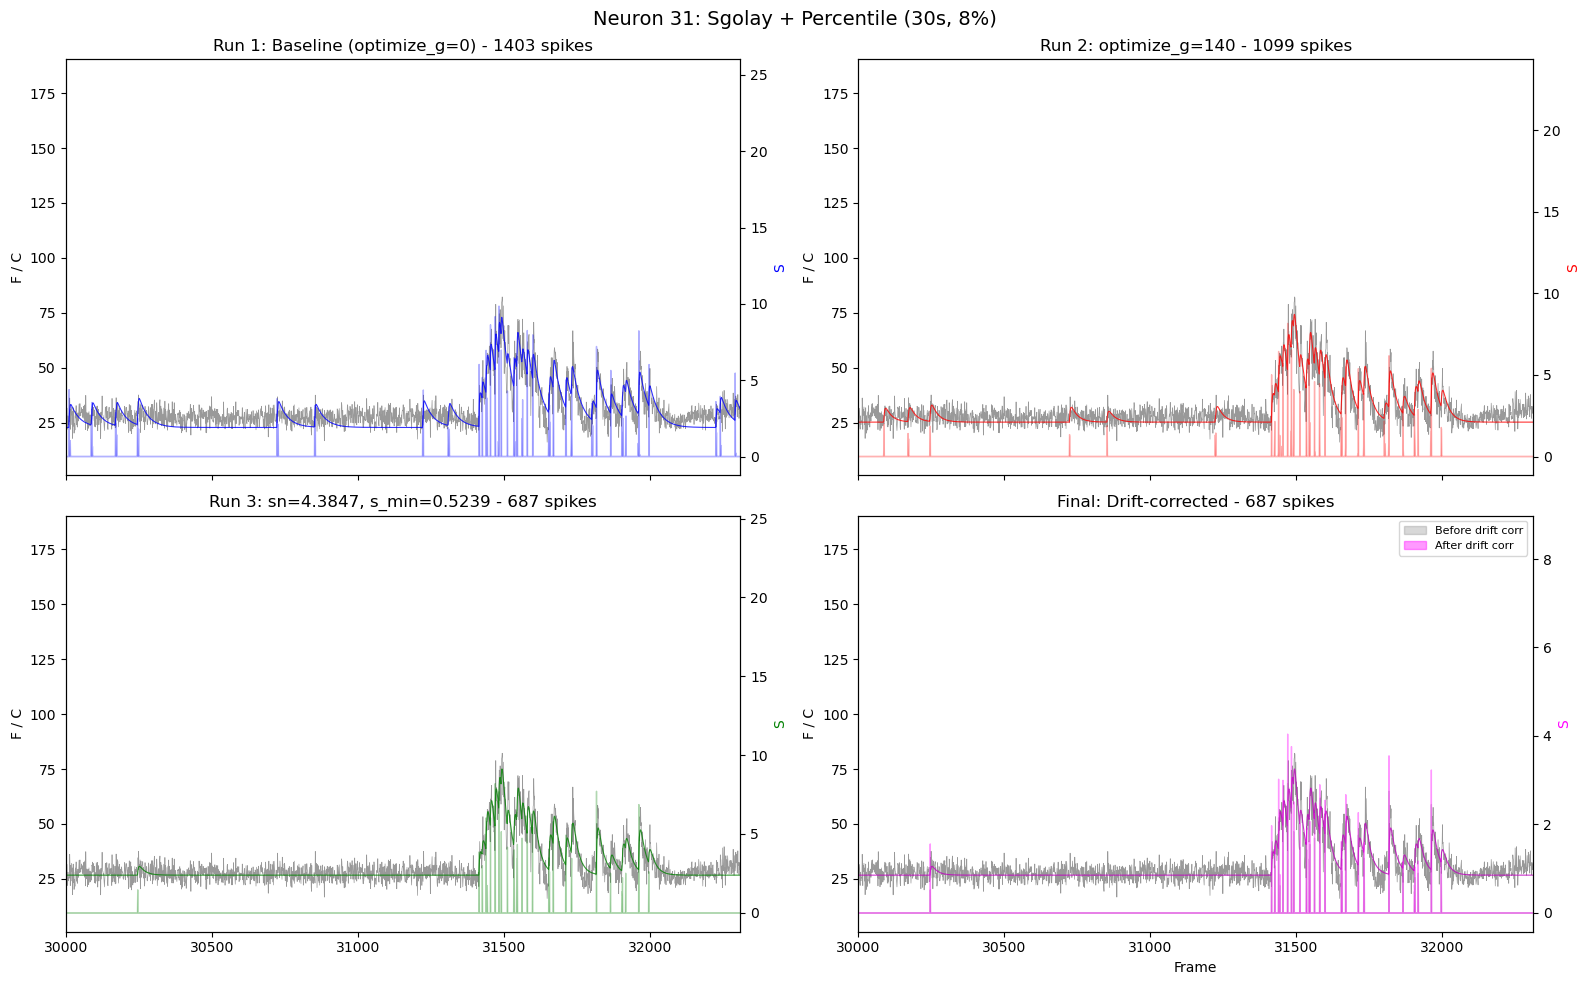

In [26]:
x_zoom = [30000, len(f_processed)]

# --- PLOT: 2x2 comparison ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)

# Run 1: Baseline
ax = axes[0, 0]
ax.plot(f_processed, 'k', alpha=0.4, linewidth=0.5)
ax.plot(scale_c(c1_run, f_processed), 'b', alpha=0.8, linewidth=0.8)
ax_twin = ax.twinx()
ax_twin.fill_between(range(len(sp1)), 0, sp1, color='blue', alpha=0.3)
ax_twin.set_ylabel('S', color='blue')
ax.set_title(f'Run 1: Baseline (optimize_g=0) - {num_spikes_run1} spikes')
ax.set_ylabel('F / C')
ax.set_xlim(x_zoom)

# Run 2: Optimize g
ax = axes[0, 1]
ax.plot(f_processed, 'k', alpha=0.4, linewidth=0.5)
ax.plot(scale_c(c2_run, f_processed), 'r', alpha=0.8, linewidth=0.8)
ax_twin = ax.twinx()
ax_twin.fill_between(range(len(sp2)), 0, sp2, color='red', alpha=0.3)
ax_twin.set_ylabel('S', color='red')
ax.set_title(f'Run 2: optimize_g={optimized_g} - {num_spikes_run2} spikes')
ax.set_ylabel('F / C')
ax.set_xlim(x_zoom)

# Run 3: refined sn + s_min + optimized g
ax = axes[1, 0]
ax.plot(f_processed, 'k', alpha=0.4, linewidth=0.5)
ax.plot(scale_c(c3_run, f_processed), 'g', alpha=0.8, linewidth=0.8)
ax_twin = ax.twinx()
ax_twin.fill_between(range(len(sp3)), 0, sp3, color='green', alpha=0.3)
ax_twin.set_ylabel('S', color='green')
ax.set_title(f'Run 3: sn={sn_refined:.4f}, s_min={s_min_threshold:.4f} - {num_spikes_run3} spikes')
ax.set_ylabel('F / C')
ax.set_xlim(x_zoom)

# Drift-corrected
ax = axes[1, 1]
ax.plot(f_processed, 'k', alpha=0.4, linewidth=0.5)
ax.plot(scale_c(c3_run, f_processed), 'm', alpha=0.8, linewidth=0.8)
ax_twin = ax.twinx()
# Overlay original (gray) and corrected (magenta)
ax_twin.fill_between(range(len(sp3)), 0, sp3 / mad, color='gray', alpha=0.3, label='Before drift corr')
ax_twin.fill_between(range(len(sp_final)), 0, sp_final, color='magenta', alpha=0.4, label='After drift corr')
ax_twin.set_ylabel('S', color='magenta')
ax_twin.legend(loc='upper right', fontsize=8)
ax.set_title(f'Final: Drift-corrected - {np.sum(sp_final > 0)} spikes')
ax.set_ylabel('F / C')
ax.set_xlabel('Frame')
ax.set_xlim(x_zoom)

plt.suptitle(f'Neuron {neuron_idx}: {method_label}', fontsize=14)
plt.tight_layout()

### Drift correction

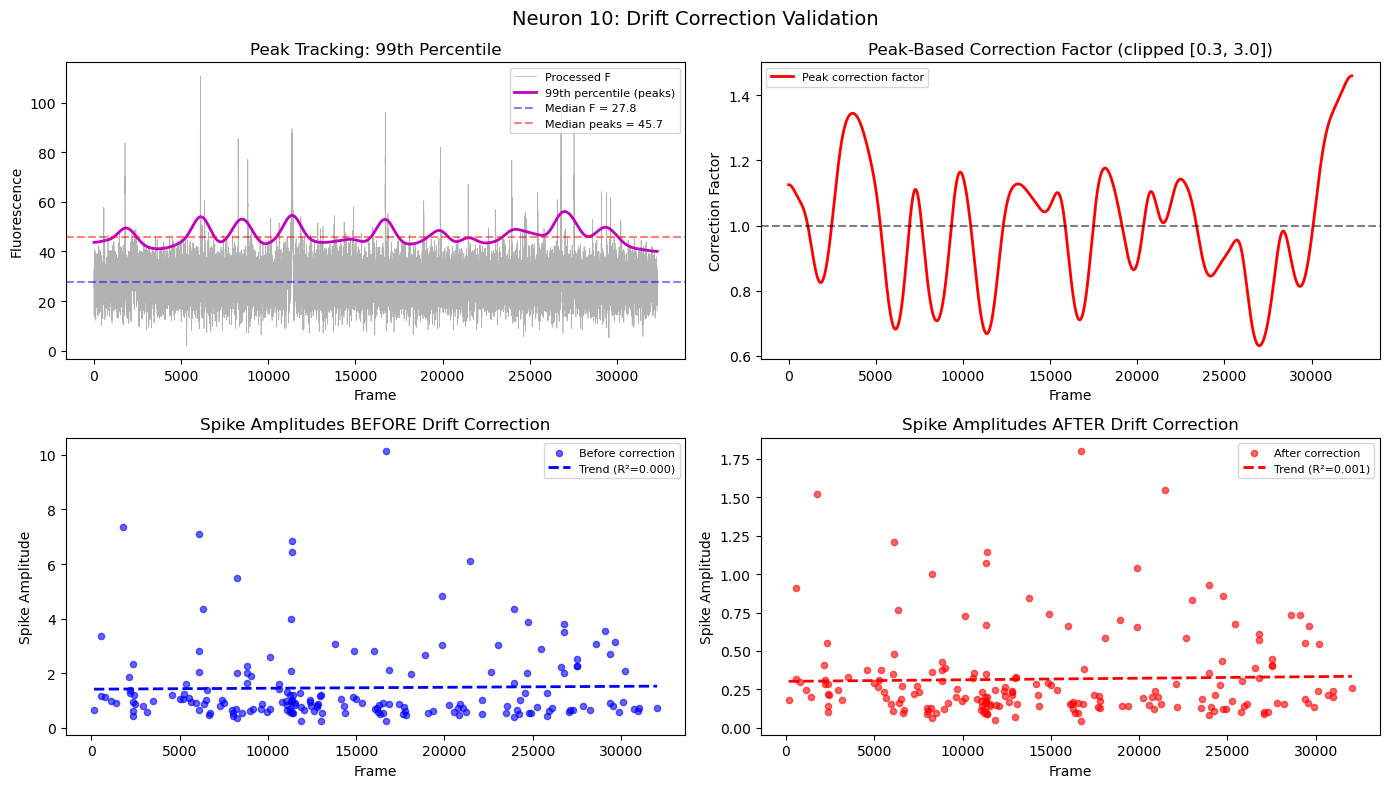


[Neuron 10] Explore the figure. Press 'n' or 'space' to continue, 'q' to quit.
Neuron_idx=10, iscell=False


In [ ]:
fig2, axes2 = plt.subplots(2, 2, figsize=(14, 8))

# Panel 1: F trace with 99th percentile peak tracking
ax = axes2[0, 0]
ax.plot(f_processed, 'k', alpha=0.3, linewidth=0.5, label='Processed F')
ax.plot(pks, 'm', linewidth=2, label='99th percentile (peaks)')
ax.axhline(med_f, color='b', linestyle='--', alpha=0.5, label=f'Median F = {med_f:.1f}')
ax.axhline(med_pks, color='r', linestyle='--', alpha=0.5, label=f'Median peaks = {med_pks:.1f}')
ax.set_xlabel('Frame')
ax.set_ylabel('Fluorescence')
ax.set_title('Peak Tracking: 99th Percentile')
ax.legend(loc='upper right', fontsize=8)

# Panel 2: Correction factor (pksTmp) over time
ax = axes2[0, 1]
ax.plot(pksTmp, 'r-', linewidth=2, label='Peak correction factor')
ax.axhline(1.0, color='k', linestyle='--', alpha=0.5)
ax.set_xlabel('Frame')
ax.set_ylabel('Correction Factor')
ax.set_title(f'Peak-Based Correction Factor (clipped [0.3, 3.0])')
ax.legend(loc='upper left', fontsize=8)

# Panel 3: Scatter of spike amplitudes before correction
ax = axes2[1, 0]
spike_times = np.where(sp3 > 0)[0]
spike_amps_before = sp3[spike_times]
ax.scatter(spike_times, spike_amps_before, c='blue', alpha=0.6, s=20, label='Before correction')
# Add linear fit to show trend
if len(spike_times) > 2:
    slope_sp, int_sp, r_sp, _, _ = linregress(spike_times, spike_amps_before)
    ax.plot(spike_times, int_sp + slope_sp * spike_times, 'b--', linewidth=2, 
            label=f'Trend (R²={r_sp**2:.3f})')
ax.set_xlabel('Frame')
ax.set_ylabel('Spike Amplitude')
ax.set_title('Spike Amplitudes BEFORE Drift Correction')
ax.legend(loc='upper right', fontsize=8)

# Panel 4: Scatter of spike amplitudes after correction
ax = axes2[1, 1]
spike_amps_after = sp_final[spike_times]
ax.scatter(spike_times, spike_amps_after, c='red', alpha=0.6, s=20, label='After correction')
# Add linear fit to show (hopefully reduced) trend
if len(spike_times) > 2:
    slope_sp2, int_sp2, r_sp2, _, _ = linregress(spike_times, spike_amps_after)
    ax.plot(spike_times, int_sp2 + slope_sp2 * spike_times, 'r--', linewidth=2,
            label=f'Trend (R²={r_sp2**2:.3f})')
ax.set_xlabel('Frame')
ax.set_ylabel('Spike Amplitude')
ax.set_title('Spike Amplitudes AFTER Drift Correction')
ax.legend(loc='upper right', fontsize=8)

plt.suptitle(f'Neuron {neuron_idx}: Drift Correction Validation', fontsize=14)
plt.tight_layout()
plt.show(block=False)